# ApexPlanet Data Analytics Internship — Task 1
## Foundational Setup & Exploratory Data Analysis (EDA)

**Dataset:** Amazon Sale Report (Amazon.in e-commerce order data, Mar–Jun 2022)
**Author:** Intern, ApexPlanet Software Pvt. Ltd.

This notebook covers:
1. Data sourcing & understanding
2. Data cleaning & preprocessing
3. Exploratory Data Analysis (univariate + bivariate)
4. Key findings & business insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Sourcing & Understanding

**Source:** `Amazon_Sale_Report.csv` — order-level e-commerce transaction data exported
from Amazon.in seller central, covering the period 31-Mar-2022 to 29-Jun-2022.

**Collection method:** Platform-generated order export (one row per order line item).

**Limitations:** Only Amazon.in orders (124 "Non-Amazon" rows present); no customer-level
identifiers; `Amount` reflects order value in INR only; some shipping and payment fields
have missing values as explored below.


In [2]:
df = pd.read_csv("../data/raw/Amazon_Sale_Report.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 128,975 rows x 24 columns


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


In [4]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))


Missing values per column:
fulfilled-by        89698
promotion-ids       49153
Unnamed: 22         49050
currency             7795
Amount               7795
Courier Status       6872
ship-postal-code       33
ship-state             33
ship-city              33
ship-country           33
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df['Date'].min(), "to", df['Date'].max())


Duplicate rows: 0
Date range: 03-31-22 to 06-29-22


## 2. Data Cleaning & Preprocessing

Cleaning steps applied (see `scripts/clean_data.py` for the reusable script):

1. Standardized column names to snake_case
2. Dropped the empty `Unnamed: 22` column
3. Removed duplicate rows (0 found)
4. Converted `Date` to datetime; categorical text columns to `category` dtype
5. Filled missing `Amount`/`currency` (7,795 rows — cancelled/₹0 orders) with 0
6. Filled missing `Courier Status` (6,872 rows) with `"Not Shipped"`
7. Dropped 33 rows missing shipping city/state/postal/country (too few to impute)
8. Converted `promotion-ids` into a boolean `has_promotion` flag
9. Filled missing `fulfilled-by` with `"Amazon Fulfilled"`
10. Flagged (not removed) `Amount` outliers using the IQR method — high-value
    orders are legitimate sales, not data errors
11. Added derived columns: `order_month`, `order_week`, `order_day`


In [6]:

import subprocess
result = subprocess.run(["python3", "clean_data.py"], cwd="../scripts",
                         capture_output=True, text=True)
print(result.stdout)



Loaded raw data: 128,975 rows x 24 columns
Standardized column names to snake_case and stripped whitespace
Dropped empty/junk columns: ['unnamed:_22']
Note: 'currency' (INR) and 'ship_country' (IN) are constant fields
Removed 0 duplicate rows (found 0)
Converted 'date' column to datetime
Converted categorical text columns to 'category' dtype
Filled 7,795 missing 'amount' values with 0 (orders with Qty=0 / Cancelled status)
Filled 6,872 missing 'courier_status' values with 'Not Shipped'
Dropped 33 rows missing shipping address details
Converted 'promotion_ids' into boolean 'has_promotion' flag
Filled missing 'fulfilled_by' with 'Amazon Fulfilled'
IQR bounds for 'amount': [-124.00, 1308.00] -> 3,169 outlier rows flagged (kept, not removed, since high-value orders are legitimate sales)
Added derived columns: order_month, order_week, order_day

Saved cleaned dataset: 128,942 rows x 27 columns -> ../data/processed/amazon_sale_report_cleaned.csv



In [7]:
df_clean = pd.read_csv("../data/processed/amazon_sale_report_cleaned.csv", low_memory=False)
df_clean['date'] = pd.to_datetime(df_clean['date'])
print(f"Cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
df_clean.head()


Cleaned shape: 128,942 rows x 27 columns


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistical Summary

In [8]:
print(df_clean[['qty', 'amount']].describe().round(2))
print()
print("Top categories by order count:")
print(df_clean['category'].value_counts())


             qty     amount
count  128942.00  128942.00
mean        0.90     609.37
std         0.31     313.36
min         0.00       0.00
25%         1.00     413.00
50%         1.00     583.00
75%         1.00     771.00
max        15.00    5584.00

Top categories by order count:
category
Set              50272
kurta            49859
Western Dress    15499
Top              10620
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


### 3.2 Univariate Analysis

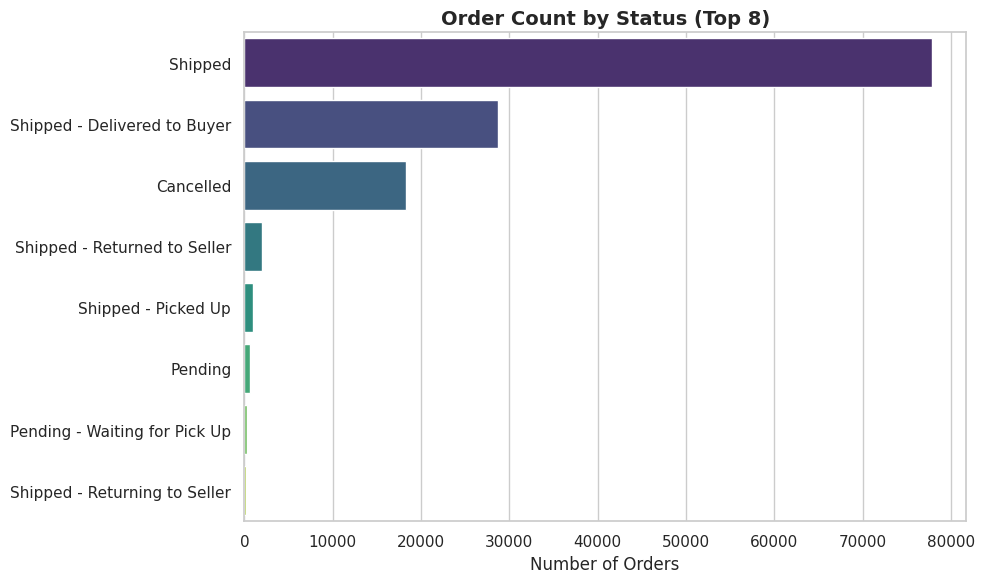

In [9]:
plt.figure(figsize=(10, 6))
order = df_clean['status'].value_counts().head(8)
sns.barplot(x=order.values, y=order.index, hue=order.index, palette="viridis", legend=False)
plt.title("Order Count by Status (Top 8)", fontsize=14, fontweight="bold")
plt.xlabel("Number of Orders"); plt.ylabel("")
plt.tight_layout()
plt.show()


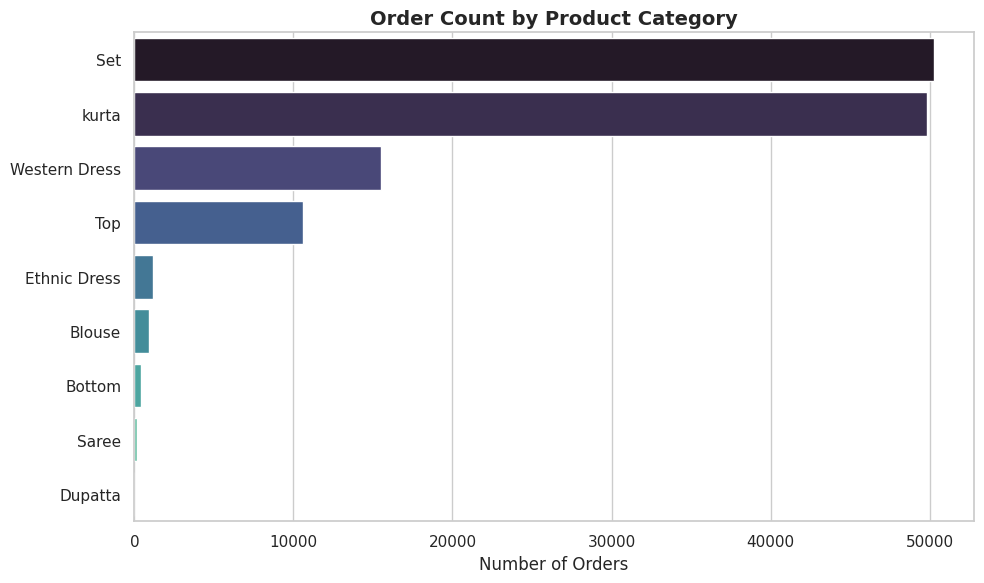

In [10]:
plt.figure(figsize=(10, 6))
cat_counts = df_clean['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette="mako", legend=False)
plt.title("Order Count by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Orders"); plt.ylabel("")
plt.tight_layout()
plt.show()


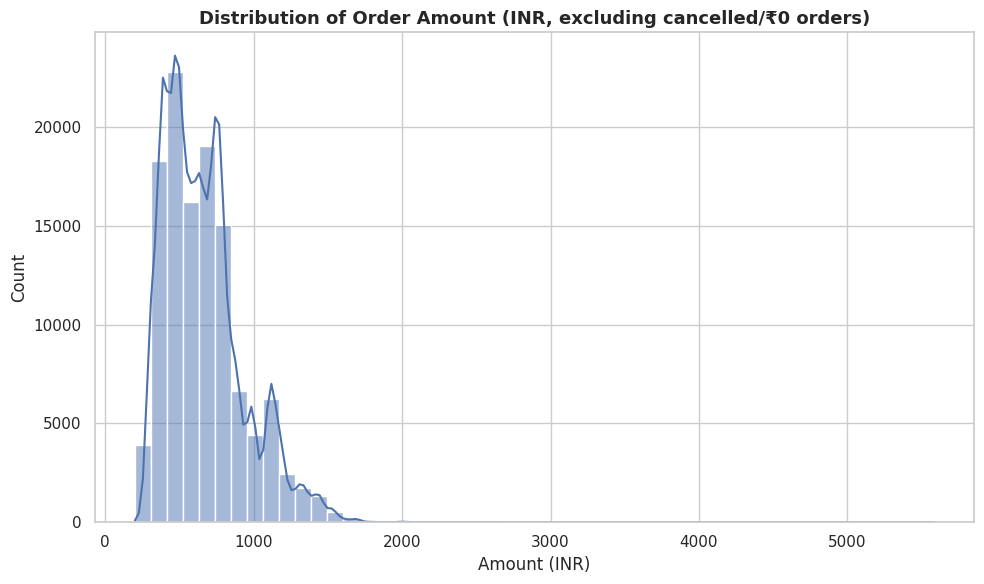

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean.loc[df_clean['amount'] > 0, 'amount'], bins=50, kde=True, color="#4c72b0")
plt.title("Distribution of Order Amount (INR, excluding cancelled/₹0 orders)", fontsize=13, fontweight="bold")
plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.show()


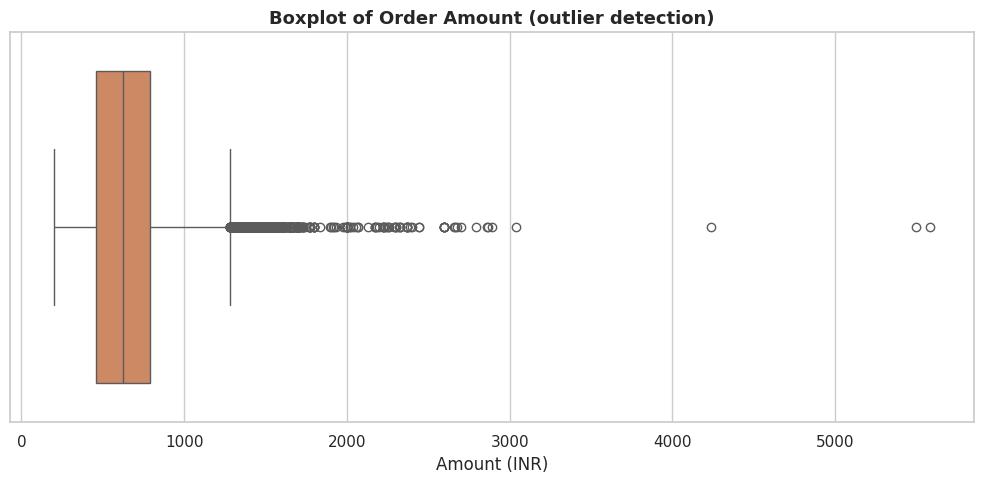

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean.loc[df_clean['amount'] > 0, 'amount'], color="#dd8452")
plt.title("Boxplot of Order Amount (outlier detection)", fontsize=13, fontweight="bold")
plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.show()


### 3.3 Bivariate & Trend Analysis

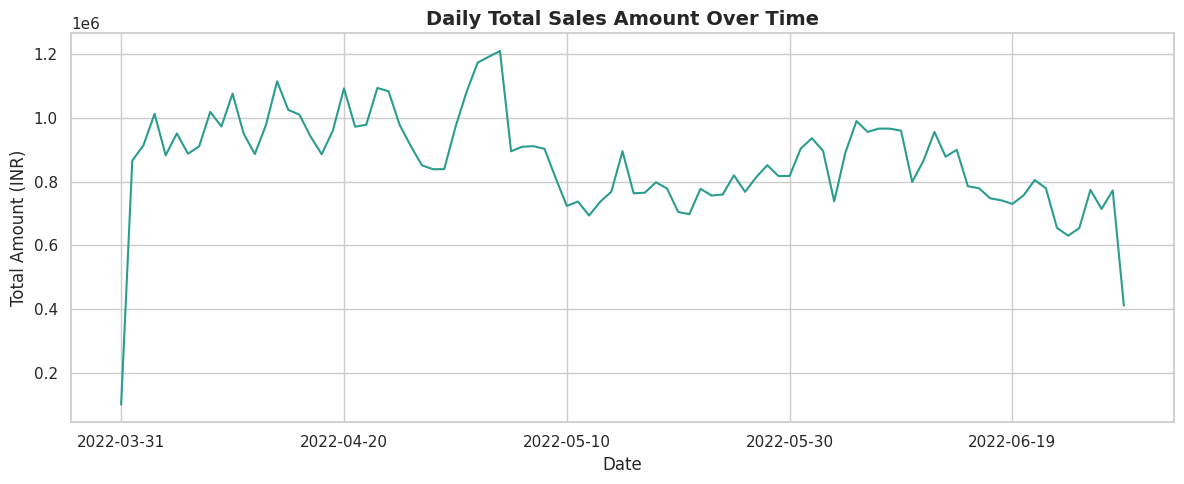

In [13]:
daily = df_clean[df_clean['amount'] > 0].groupby('order_day')['amount'].sum()
plt.figure(figsize=(12, 5))
daily.plot(color="#2a9d8f")
plt.title("Daily Total Sales Amount Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date"); plt.ylabel("Total Amount (INR)")
plt.tight_layout()
plt.show()


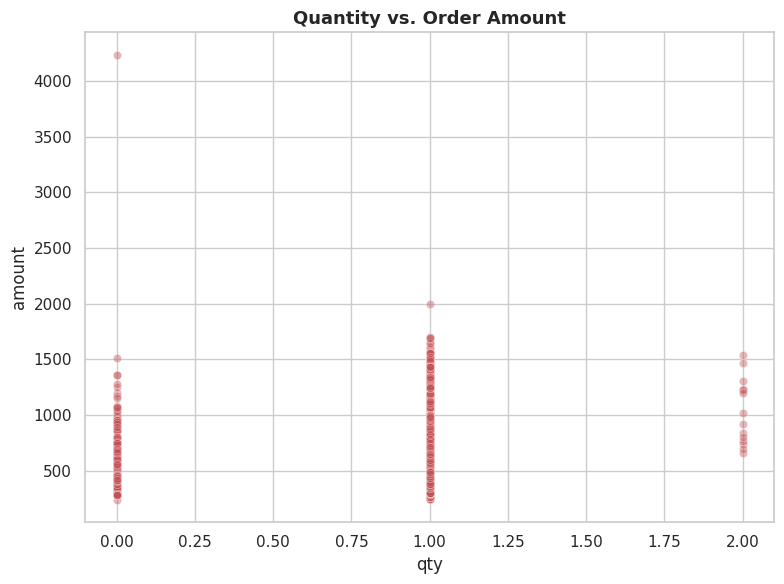

In [14]:
sample = df_clean[df_clean['amount'] > 0].sample(min(5000, (df_clean['amount'] > 0).sum()), random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x='qty', y='amount', alpha=0.4, color="#c44e52")
plt.title("Quantity vs. Order Amount", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


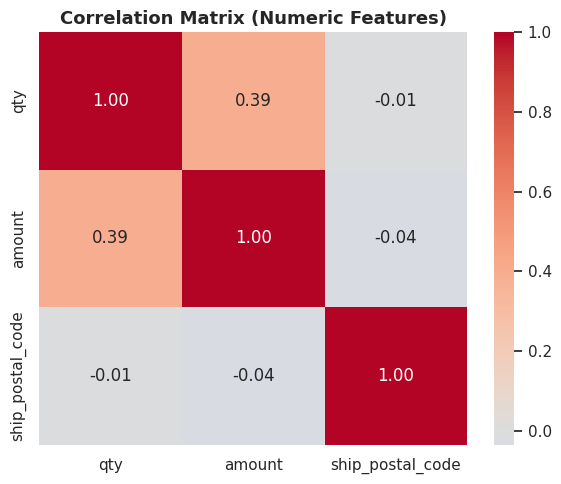

In [15]:
plt.figure(figsize=(6, 5))
num_cols = ['qty', 'amount', 'ship_postal_code']
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


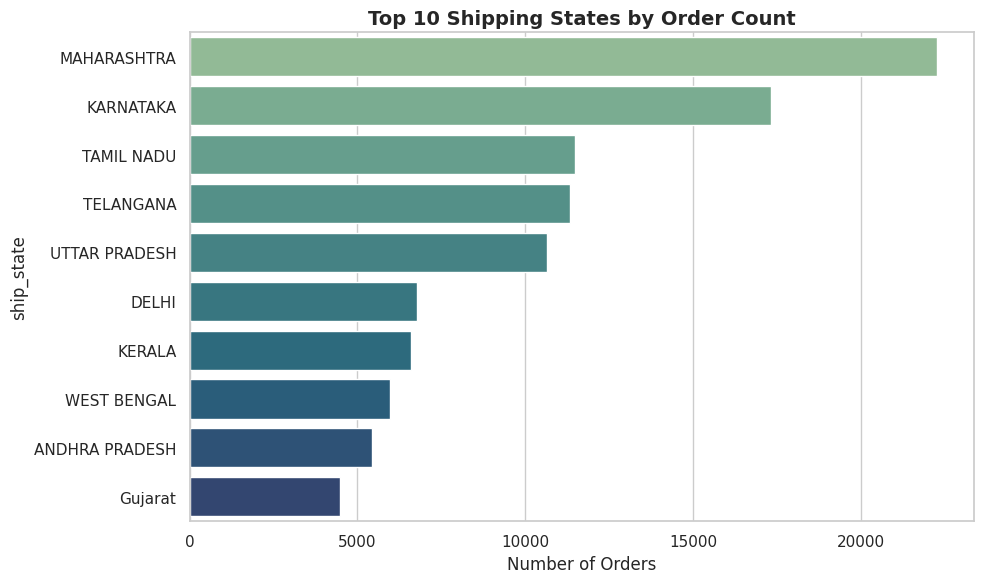

In [16]:
plt.figure(figsize=(10, 6))
top_states = df_clean['ship_state'].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, hue=top_states.index, palette="crest", legend=False)
plt.title("Top 10 Shipping States by Order Count", fontsize=14, fontweight="bold")
plt.xlabel("Number of Orders")
plt.tight_layout()
plt.show()


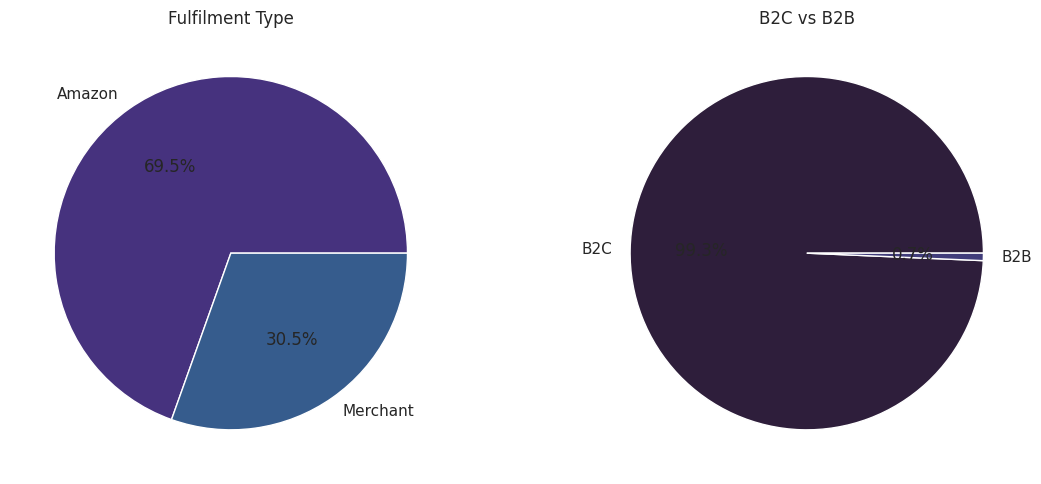

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_clean['fulfilment'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=sns.color_palette("viridis"))
axes[0].set_ylabel(""); axes[0].set_title("Fulfilment Type")
df_clean['b2b'].value_counts().rename({False: 'B2C', True: 'B2B'}).plot.pie(
    autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette("mako"))
axes[1].set_ylabel(""); axes[1].set_title("B2C vs B2B")
plt.tight_layout()
plt.show()


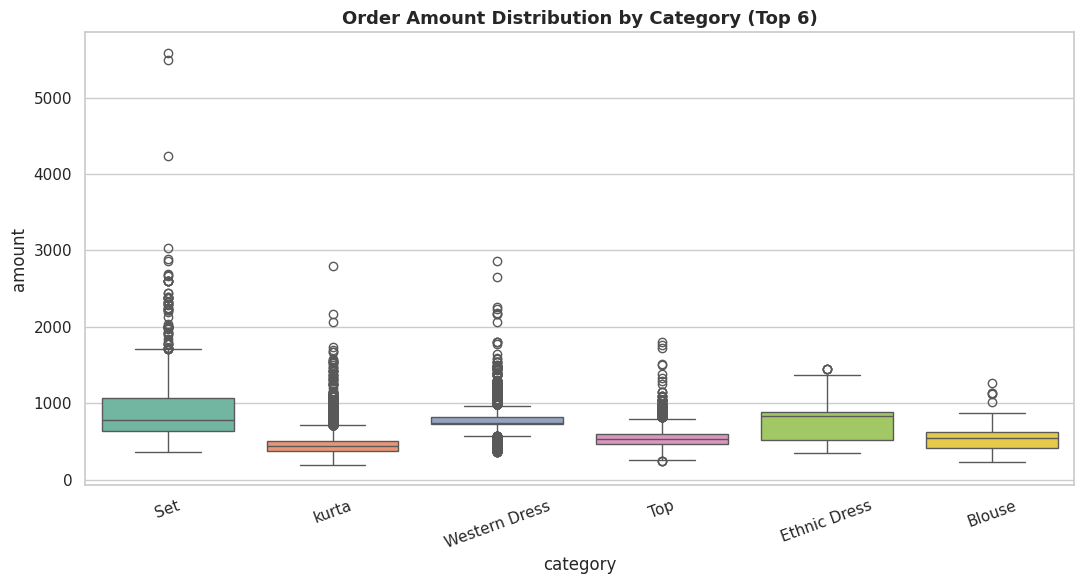

In [18]:
top_cats = df_clean['category'].value_counts().head(6).index
sub = df_clean[(df_clean['category'].isin(top_cats)) & (df_clean['amount'] > 0)]
plt.figure(figsize=(11, 6))
sns.boxplot(data=sub, x='category', y='amount', hue='category', palette="Set2", legend=False)
plt.title("Order Amount Distribution by Category (Top 6)", fontsize=13, fontweight="bold")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Key Findings

1. **Cancellation rate is significant:** ~14.2% of all orders are `Cancelled`, and a
   further ~1.5% are `Shipped - Returned to Seller` — together representing meaningful
   lost/reversed revenue worth investigating (e.g. by category or state).
2. **Category concentration:** `Set` (39%) and `kurta` (39%) together make up ~78% of
   all orders — the catalog is heavily concentrated in two categories, with `Saree` and
   `Dupatta` being negligible volume.
3. **Order value is fairly tight:** the median order amount is ₹583 (IQR ₹413–₹771);
   the IQR method flags ~2.5% of orders as high-value outliers (up to ₹5,584), which
   are legitimate premium purchases rather than data errors.
4. **Sales show a declining trend:** daily sales peaked in early May (~₹1.2M/day) after
   ramping up through April, then trended downward through June — worth correlating
   with promotions, seasonality, or catalog changes.
5. **Qty vs. Amount is only loosely correlated:** most orders are single-unit (`Qty=1`,
   75th percentile), so `Amount` is driven more by product price than quantity ordered.
6. **Geographic concentration:** a handful of states (led by Maharashtra, Karnataka,
   and others in the top 10) account for a disproportionate share of orders — useful
   for regional logistics/marketing prioritization.
7. **Fulfilment is Amazon-dominated:** the majority of orders are Amazon-fulfilled
   rather than Merchant-fulfilled, and B2B orders are a small (<1%) share of volume.

## 5. Next Steps
- Task 2 will extract these insights via SQL for repeatable, query-driven reporting.
- Task 3 will turn these charts into an interactive Power BI / Tableau dashboard.
- Task 4 will apply statistical testing, forecasting, and clustering to dig deeper into
  the cancellation drivers and sales decline observed above.
